# Heavy ion jet quenching with ***ATLAS*** Open Data
### Data
Based on arXiv:1011.6182v2


In [178]:
# File reading
import uproot
# Analysis
import awkward as ak
import numpy as np
# Plotting
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica","Arial","Nimbus Sans","DejaVu Sans"],
    "svg.fonttype": "path"
})

# Constants
MeVtoGeV = 1e-3
MeVtoTeV = 1e-6

print(uproot.__version__)

5.6.9


In [179]:
# - Useful plotting functions - #
# Use innerward facing ticks in all direction
def inner_ticks(ax:matplotlib.axes.Axes):
    ax.tick_params(direction="in",which="both",top=True,right=True)

# Plot an ATLAS Open Data label on a pair of axes
def atlas_label(ax:matplotlib.axes.Axes,loc="upper right",text="Open Data",fontsize=16,pos_ovr=None,msg=r"PbPb $\sqrt{s}=5.02\ \mathrm{TeV}$",mc=False,msg_offset=.05):
    locs = {
        "upper left" : (.04, .88),
        "upper right": (.96, .88),
    }
    if (pos_ovr is not None) and isinstance(pos_ovr,tuple):
        pos = pos_ovr 
    else: pos = locs[loc]
    align = ("left","right","center"); ha = "left"
    for a in align:
        if a in loc: ha = a
    ax.text(
        *pos,r"$\mathbfit{ATLAS}$ "+text,
        transform=ax.transAxes,fontsize=fontsize,ha=ha,va="bottom"
    )
    if msg:
        if mc: msg = r"PbPb MC $\sqrt{s}=5.02\ \mathrm{TeV}$"
        ax.text(
            pos[0], pos[1]-msg_offset, msg,
            transform=ax.transAxes, fontsize=fontsize*.75, ha=ha, va="bottom"
        )

In [180]:
# Cutting functions
def cut_n_jets(jets:ak.Array,N=2)->ak.Array:
    return jets[ak.num(jets) >= N]

def et(jets:ak.Array):
    return np.sqrt(jets["pt"]*jets["pt"] + jets["m"]*jets["m"]/(np.cosh(jets["eta"])*np.cosh(jets["eta"])))
# ET1 > 100 GeV
def cut_leading_et(jets:ak.Array,leading=100)->ak.Array:
    jets["et"] = et(jets)
    jets = jets[ak.argsort(jets["et"],axis=1,ascending=False)]
    return jets[jets["et"][:,0]*MeVtoGeV > leading]

def deltaphi(phi1,phi2):
    return np.abs((phi2 - phi1 + np.pi) % (2*np.pi) - np.pi)
def cut_deltaphi(jets:ak.Array):
    jets["leading_deltaphi"] = deltaphi(ak.firsts(jets["phi"]),jets["phi"])
    jets = jets[(jets["leading_deltaphi"] > np.pi*7/8) | (ak.local_index(jets["leading_deltaphi"]) == 0)] 
    return jets[ak.num(jets) >= 2]

def cut_subleading_et(jets:ak.Array,subleading=25):
    return jets[jets["et"][:,1]*MeVtoGeV > subleading]

def cut_et(jets:ak.Array,leading=100,subleading=25)->ak.Array:
    jets["et"] = np.sqrt(jets["pt"]*jets["pt"] + jets["m"]*jets["m"])
    jets = jets[ak.argsort(jets["et"],axis=1,ascending=False)]
    leading_mask = jets["et"][:,0]*MeVtoGeV > leading
    subleading_mask = jets["et"][:,1]*MeVtoGeV > subleading
    return jets[leading_mask & subleading_mask]

def cut_eta(jets:ak.Array,eta=2.8):
    return jets[np.abs(jets["eta"][:,0]) < eta]

def transform_deltaphi(jets:ak.Array):
    dphi = jets["phi"][:,0] - jets["phi"][:,1]
    dphi = (dphi + np.pi) % (2*np.pi) - np.pi
    return dphi

# Get the number of entries in a jagged awkward array
def get_entries(array:ak.Array):
    return ak.sum(ak.num(array))

# Function to update cutflow dictionary after applying a cut to jets
def update_cutflow(cut:str,jets:ak.Array,cutflow:dict):
    cutflow["event"][cut], cutflow["track"][cut] = len(jets), get_entries(jets)

In [181]:
# Group event numbers by centrality
centrality_ranges = {
    "(40 - 100)%": {
        "upper": 100, # TeV
        "lower": 40. # TeV
    },
    "(20 - 40)%": {
        "upper": 40,
        "lower": 20
    },
    "(10 - 20)%": {
        "upper": 20,
        "lower": 10
    },
    "(0 - 10)%": {
        "upper": 10,
        "lower": 0
    }
}
def group_by_centrality(fcal:ak.Array)->dict:
    for range in centrality_ranges:
        upper, lower = centrality_ranges[range]["upper"], centrality_ranges[range]["lower"]
        upper_mask, lower_mask = fcal["CentralityMax"] < upper, fcal["CentralityMin"] >= lower
        centrality_ranges[range]["event_numbers"] = fcal[upper_mask & lower_mask]["eventNumber"]

    return centrality_ranges

In [182]:
def get_jets_fcal(path:str):
    with uproot.open(path) as tree:
        # Fill array with jet kinematics
        # Branches are renamed from full branch names to e.g. "pt"
        jets = ak.zip({
            branch.split("_")[1]: tree[branch].array() for branch in (
                "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_pt",
                "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_eta",
                "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_phi",
                "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_m"
            )
        } | {
            "eventNumber": tree["EventInfoAuxDyn.eventNumber"].array()
        })

        # Fill FCal transverse energies and similarly reformat branch names
        fcal = ak.zip({
            branch.split(".")[1]: tree[branch].array() for branch in (
                f"EventInfoAuxDyn.FCalEt{x}" for x in ("A","C")
            )
        } | {
            branch.split(".")[1]: tree[branch].array() for branch in (
                f"EventInfoAuxDyn.Centrality{x}" for x in ("Min","Max")
            )
        }| {
            "eventNumber": tree["EventInfoAuxDyn.eventNumber"].array()
        })
    return jets, fcal

In [183]:
def plot_pt(jets:ak.Array,mc=False):
    pt = ak.flatten(jets["pt"]*MeVtoGeV)
    pt_max = max(pt)
    # h_max = np.ceil(pt_max/25)*25

    h, bin_edges = np.histogram(pt,bins=40,range=(0,250),density=True)
    fig, ax = plt.subplots()
    ax.stairs(h,bin_edges,color="blue")
    ax.set_xlim(0,250)
    ax.set_xlabel(r"Jet $p_\mathrm{T}$ [GeV]"); ax.set_ylabel(r"Probability density [GeV$^{-1}$]")

    atlas_label(ax,mc=mc)
    inner_ticks(ax)

def plot_leading_subleading_pt(jets:ak.Array,mc=False,subleading=True):
    pt = jets["pt"][:,1 if subleading else 0]*MeVtoGeV
    pt_max = ak.max(pt)
    # h_max = np.ceil(pt_max/25)*25

    h, bin_edges = np.histogram(pt,bins=40,range=(0,250),density=True)
    fig, ax = plt.subplots()
    ax.stairs(h,bin_edges,color="blue")
    ax.set_xlim(0,250)
    ax.set_xlabel("{0}".format("Subleading" if subleading else "Leading")+r" jet $p_\mathrm{T}$ [GeV]"); ax.set_ylabel(r"Probability density [GeV$^{-1}$]")
    ax.margins(0,0.2)

    atlas_label(ax,mc=mc)
    inner_ticks(ax)


In [184]:
def apply_cuts(jets:ak.Array,fcal:ak.Array,mc=False,plot=False):
    this_cutflow = {
        "event": {},
        "track": {}
    }
    update_cutflow("initial",jets,this_cutflow)
    
    jets = cut_n_jets(jets); update_cutflow("n_jets",jets,this_cutflow)
    jets = cut_leading_et(jets); update_cutflow("et_leading",jets,this_cutflow)
    jets = cut_deltaphi(jets); update_cutflow("Delta phi",jets,this_cutflow)
    jets = cut_subleading_et(jets); update_cutflow("et_subleading",jets,this_cutflow)
    jets = cut_eta(jets); update_cutflow("eta_leading",jets,this_cutflow)

    xlabels = [scope for scope in this_cutflow["event"]]

    if plot:
        fig, (ax1,ax2) = plt.subplots(2,1,sharex=True)
        ax1.bar(xlabels,[this_cutflow["track"][scope] for scope in xlabels],width=1.,linewidth=.5,edgecolor="k",color="blue")
        ax1.margins(x=0)
        ax1.set_ylabel(r"$N_\mathrm{tracks}$")
        ax2.bar(xlabels,[this_cutflow["event"][scope] for scope in xlabels],width=1.,linewidth=.5,edgecolor="k",color="blue")
        ax2.set_ylabel(r"$N_\mathrm{events}$")
        ax2.set_xlabel("Cut")
        for ax in (ax1,ax2): inner_ticks(ax)
        atlas_label(ax1,pos_ovr=(.96,.78),msg_offset=.1)
    return jets, fcal

def plot_n_jets(jets:ak.Array,mc=False):
    n_jets = ak.flatten(ak.num(jets),axis=None)
    h, bin_edges = np.histogram(n_jets,max(n_jets),range=(0,max(n_jets)))
    
    fig, ax = plt.subplots()
    ax.stairs(h,bin_edges,color="blue")
    ax.set_xlim(0,max(n_jets))
    ax.set_xlabel(r"$N_\mathrm{jets}$"); ax.set_ylabel("Number of events")
    atlas_label(ax); inner_ticks(ax)
    ax.margins(y=.2)

    return n_jets, fig

def plot_n_jets_centrality(jet_centralities:dict,mc=False):
    fig, ax = plt.subplots()
    cols = ["black","blue","green","red"]
    n_max = 0
    for i,c in enumerate(jet_centralities):
        n_jets = ak.flatten(ak.num(jet_centralities[c]),axis=None)
        h, bin_edges = np.histogram(n_jets,max(n_jets),range=(0,max(n_jets)))
        ax.stairs(h,bin_edges,color=cols[i],label=c)
        n_max = max(n_jets) if max(n_jets) > n_max else n_max
    ax.set_xlim(0,max(n_jets))
    ax.set_xlabel(r"$N_\mathrm{jets}$"); ax.set_ylabel("Number of events")
    atlas_label(ax,mc=mc); inner_ticks(ax)
    ax.margins(y=.2)
    ax.legend(frameon=False,loc="upper left")

In [185]:
def bin_jets_by_centrality(jets:ak.Array,fcal:ak.Array):
    centralities = group_by_centrality(fcal)
    # Grab jet event numbers.
    # Only the first number need be taken as this will
    # be repeated for every jet in an event.
    jet_enums = jets["eventNumber"][:,0]

    jet_centralities = {c: jets[np.isin(jet_enums,centralities[c]["event_numbers"])] for c in centralities}

    return jet_centralities

# Calculate dijet asymmetry factor A_J
def calculate_aj(jets:ak.Array):
    AJ = (jets["et"][:,0]-jets["et"][:,1])/(jets["et"][:,0]+jets["et"][:,1])
    return AJ
def plot_aj(jet_centralities:dict,mc=False):
    fig, ax = plt.subplots()
    AJ = {c: calculate_aj(jet_centralities[c]) for c in jet_centralities}
    max_aj = np.ceil((np.max(np.concatenate([AJ[c] for c in AJ])))*1e2)*1e-2
    h_range = (0,1)
    
    cols = ["black","blue","green","red"]
    for i,c in enumerate(AJ):
        h, bin_edges = np.histogram(AJ[c],bins=40,range=h_range,density=False)
        ax.stairs(h,bin_edges,label=c,color=cols[i])

    ax.set_xlabel(r"Dijet $A_J$"); ax.set_ylabel(r"Number of events")
    atlas_label(ax,mc=mc)
    inner_ticks(ax)

    ax.legend(frameon=False,loc="upper left")
    ax.margins(y=.4)
    ax.set_xlim(h_range)

    return AJ, fig

# Plot delta phi
def plot_delta_phi(jet_centralities:dict,mc=False):
    fig, ax = plt.subplots()
    DPhi ={c: transform_deltaphi(jet_centralities[c]) for c in jet_centralities}

    h_range = (0, np.ceil(2*np.pi*10)*.1)

    cols = ["black","blue","green","red"]
    for i,c in enumerate(DPhi):
        h, bin_edges = np.histogram(DPhi[c],bins=20,range=h_range)
        h = h/len(DPhi)
        ax.stairs(h,bin_edges,label=c,color=cols[i])

    ax.set_xlabel(r"Dijet $|\Delta\phi'|$"); ax.set_ylabel(r"Probability density")
    atlas_label(ax,mc=mc)
    inner_ticks(ax)

    ax.legend(frameon=False,loc="upper left")
    ax.margins(y=.4)
    ax.set_xlim(h_range)

    return DPhi, fig

def plot_et1_et2(jets:ak.Array):
    ET1, ET2 = ak.to_numpy(jets["et"][:,0])*MeVtoGeV, ak.to_numpy(jets["et"][:,1])*MeVtoGeV
    print(ET1,ET2)

    fig, ax = plt.subplots()
    ax.hist2d(ET1,ET2,bins=40,range=[(100,250),(25,250)],cmap="plasma")
    ax.set_xlabel(r"$E_\mathrm{T1}$ [GeV]"); ax.set_ylabel(r"$E_\mathrm{T2}$ [GeV]")
    ax.plot([0,250],[0,250],color="red")

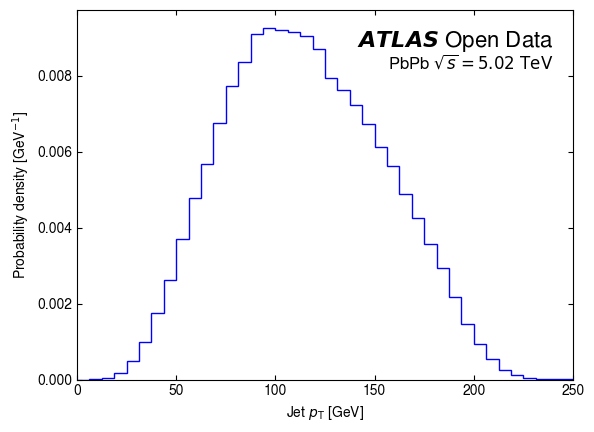

In [186]:
# Get data
jets, fcal = get_jets_fcal("DAOD_HIONHPOD_DATA.output.pool.root:CollectionTree")
# jets, fcal = get_jets_fcal("DAOD_HIONHPOD_minbias_data.root:CollectionTree")
cut_deltaphi(jets)
plot_pt(jets)

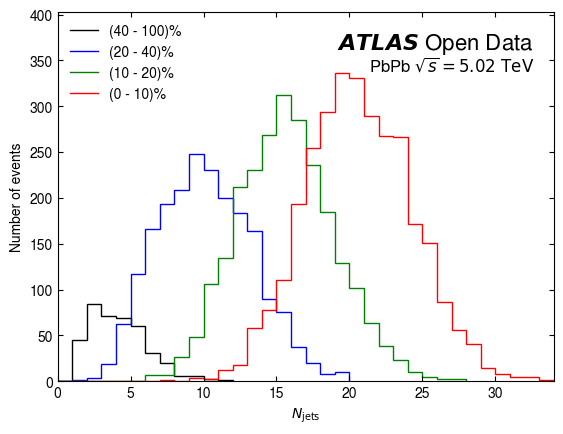

In [187]:
jet_centralities = bin_jets_by_centrality(jets,fcal)
plot_n_jets_centrality(jet_centralities)

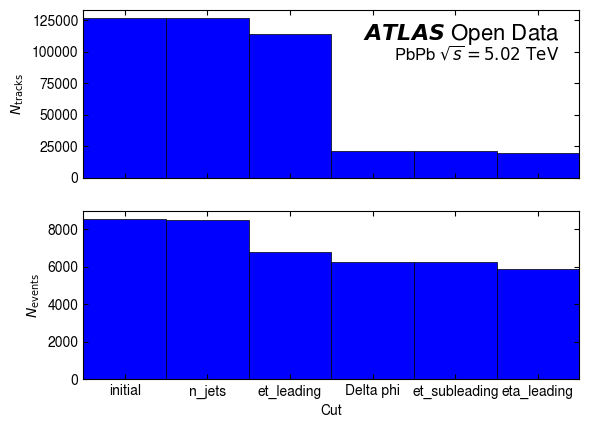

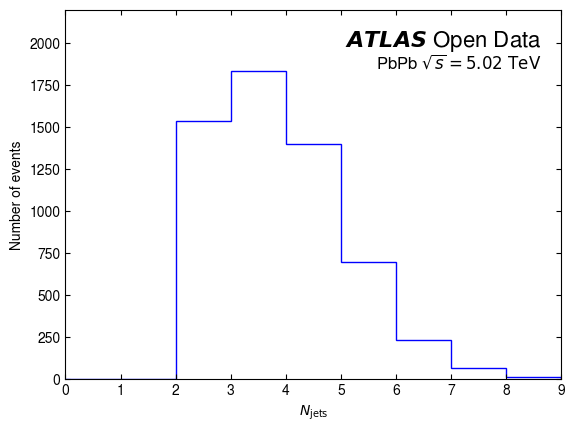

In [188]:
jets, fcal = apply_cuts(jets,fcal,plot=True)
n_jets, fig = plot_n_jets(jets)

[172.815046875 110.83877343750001 166.93225 ... 196.895703125
 203.131046875 167.85387500000002] [156.637203125 83.77715625 144.815546875 ... 182.751578125 154.142
 154.0230625]


({'(40 - 100)%': <Array [-2.79, 3.09, -2.78] type='3 * ?float32'>,
  '(20 - 40)%': <Array [-2.96, -3.13, -2.95, ..., 2.94, -3.06, -3.02] type='606 * ?float32'>,
  '(10 - 20)%': <Array [-2.88, -3.06, 2.94, ..., -2.76, 2.91, 3.14] type='2068 * ?float32'>,
  '(0 - 10)%': <Array [2.79, 2.85, -3.1, 2.94, ..., 3.08, 2.78, -3.11] type='2711 * ?float32'>},
 <Figure size 640x480 with 1 Axes>)

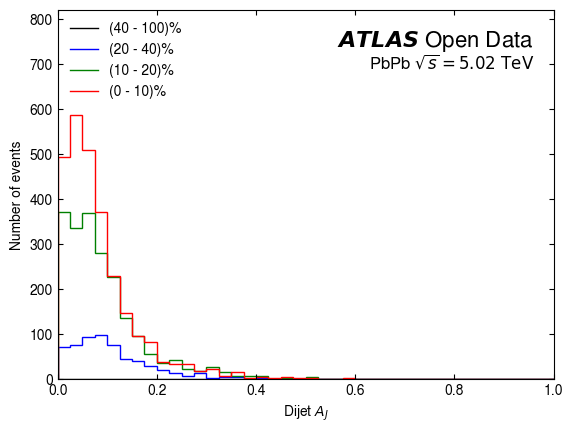

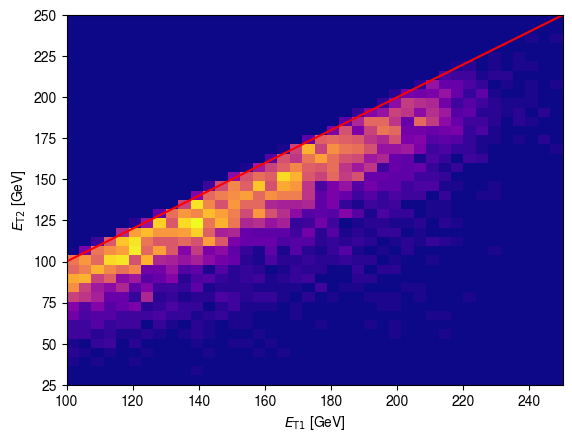

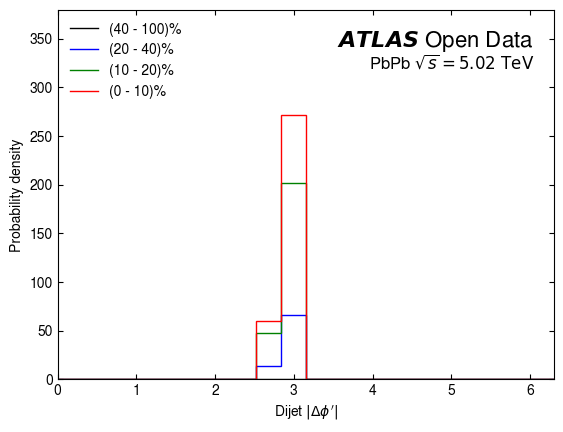

In [189]:
jet_centralities = bin_jets_by_centrality(jets,fcal)
plot_aj(jet_centralities)
plot_et1_et2(jets)
plot_delta_phi(jet_centralities)

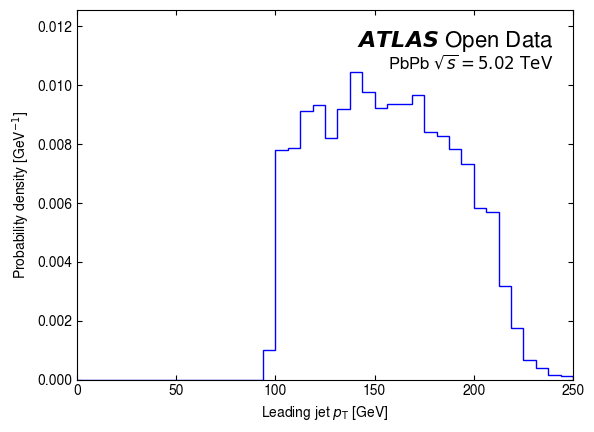

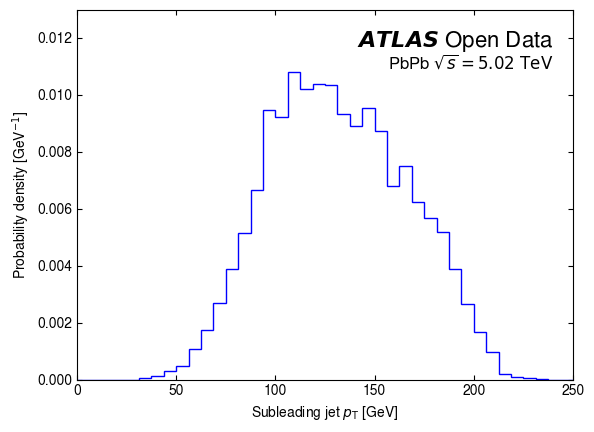

In [190]:
plot_leading_subleading_pt(jets,subleading=False)
plot_leading_subleading_pt(jets,subleading=True)

In [191]:
centralities = group_by_centrality(fcal)
jet_eventNumbers = jets["eventNumber"][:,0]
central_jets = jets[np.isin(jet_eventNumbers,centralities["(0 - 10)%"]["event_numbers"])]
peripheral_jets = jets[np.isin(jet_eventNumbers,centralities["(10 - 20)%"]["event_numbers"])]
print(central_jets["pt"])

[[1.71e+05, 1.55e+05, 9.79e+04], [...], ..., [2.02e+05, 1.48e+05, 1.14e+05]]


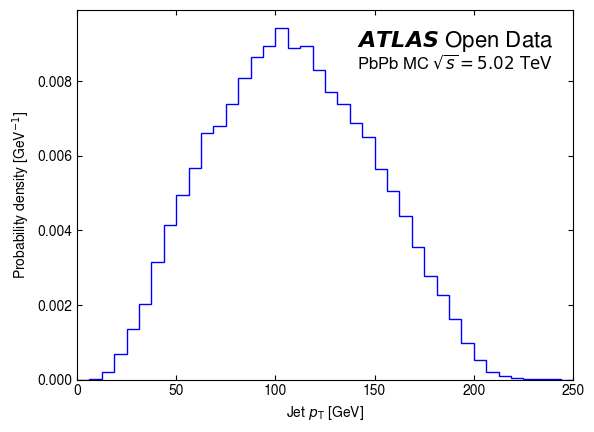

In [192]:
mc_jets, mc_fcal = get_jets_fcal("DAOD_nothinning_jetsmc.root:CollectionTree")
plot_pt(mc_jets,mc=True)

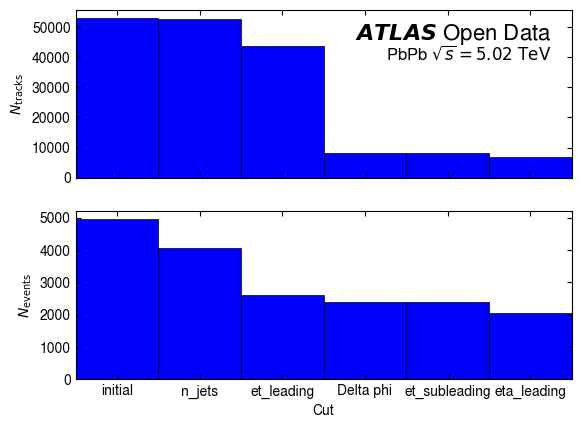

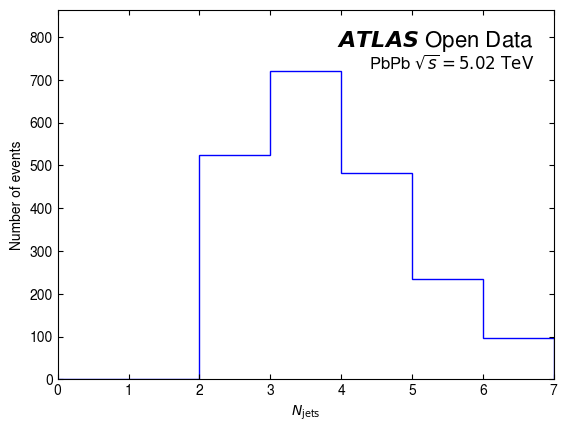

In [193]:
mc_jets, mc_fcal = apply_cuts(mc_jets,mc_fcal,mc=True,plot=True)
n_jets, fig = plot_n_jets(mc_jets,mc=True)

({'(40 - 100)%': <Array [-3.06] type='1 * ?float32'>,
  '(20 - 40)%': <Array [2.85, -3, 3.13, -3.04, ..., 3.06, 2.99, -2.91] type='104 * ?float32'>,
  '(10 - 20)%': <Array [3.08, 2.84, 3.08, -2.76, ..., -3.08, 2.83, 3.13] type='837 * ?float32'>,
  '(0 - 10)%': <Array [-2.98, 3.08, -3.1, 2.76, ..., -2.94, -3, 3.14] type='971 * ?float32'>},
 <Figure size 640x480 with 1 Axes>)

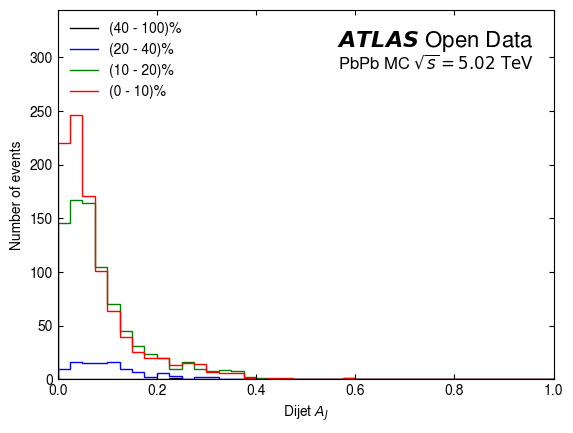

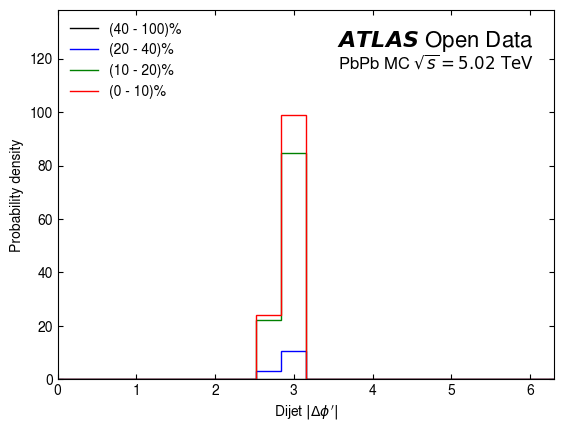

In [194]:
mc_jet_centralities = bin_jets_by_centrality(mc_jets,mc_fcal)
plot_aj(mc_jet_centralities,mc=True)
plot_delta_phi(mc_jet_centralities,mc=True)

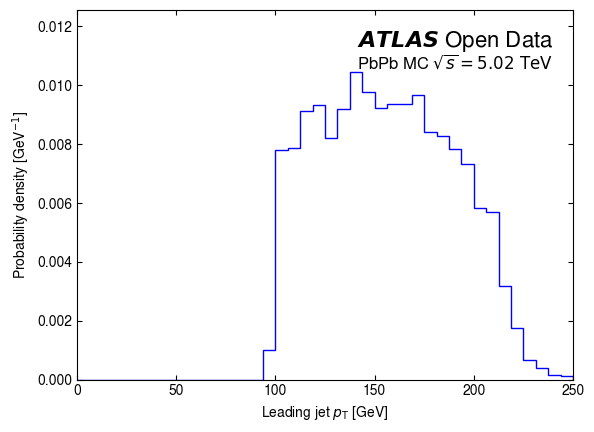

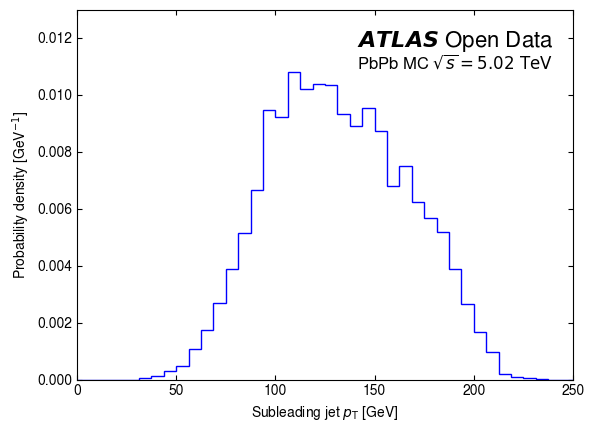

In [195]:
plot_leading_subleading_pt(jets,subleading=False,mc=True)
plot_leading_subleading_pt(jets,subleading=True,mc=True)

In [196]:
def process_file(file_path:str,H_c:dict,h_nbins:int,h_range:tuple,mc=False):
    jets, fcal = get_jets_fcal(file_path)
    jets, fcal = apply_cuts(jets,fcal,mc=mc)
    jet_centralities = bin_jets_by_centrality(jets,fcal)
    AJ = {c: calculate_aj(jet_centralities[c]) for c in jet_centralities}
    for c in jet_centralities:
        h, bin_edges = np.histogram(AJ[c],h_nbins,h_range)
        H_c[c] = H_c[c] + h

    return H_c, bin_edges

def plot_aj_from_dict(H_c:dict,bin_edges:np.ndarray):
    fig,ax = plt.subplots()
    cols = ["black","blue","green","red"]
    for i,c in enumerate(H_c):
        ax.stairs(H_c[c]/(np.sum(H_c[c])),bin_edges,label=f"{c} N={int(np.sum(H_c[c]))}",color=cols[i])
    atlas_label(ax); inner_ticks(ax)
    ax.set_xlabel(r"Dijet $A_\mathrm{J}$"); ax.set_ylabel("Probability density")
    ax.legend(frameon=False,loc="upper left")
    ax.margins(y=.35)

In [197]:
import glob
input_files = sorted(glob.glob("/data/rjackson/HISample/DataAODs/DAODs/DAOD*.root"))
print(input_files)
h_nbins, h_range = 20, (0,1)
H_c =  {c: np.histogram([-1],h_nbins,h_range)[0] for c in centrality_ranges}
for f in input_files:
    H_c, bin_edges = process_file(f"{f}:CollectionTree",H_c,h_nbins,h_range)

['/data/rjackson/HISample/DataAODs/DAODs/DAOD_HIONHPOD.output.pool.0.root', '/data/rjackson/HISample/DataAODs/DAODs/DAOD_HIONHPOD.output.pool.1.root', '/data/rjackson/HISample/DataAODs/DAODs/DAOD_HIONHPOD.output.pool.2.root', '/data/rjackson/HISample/DataAODs/DAODs/DAOD_HIONHPOD.output.pool.3.root', '/data/rjackson/HISample/DataAODs/DAODs/DAOD_HIONHPOD.output.pool.4.root', '/data/rjackson/HISample/DataAODs/DAODs/DAOD_HIONHPOD.output.pool.5.root', '/data/rjackson/HISample/DataAODs/DAODs/DAOD_HIONHPOD.output.pool.6.root', '/data/rjackson/HISample/DataAODs/DAODs/DAOD_HIONHPOD.output.pool.7.root', '/data/rjackson/HISample/DataAODs/DAODs/DAOD_HIONHPOD.output.pool.8.root', '/data/rjackson/HISample/DataAODs/DAODs/DAOD_HIONHPOD.output.pool.9.root']


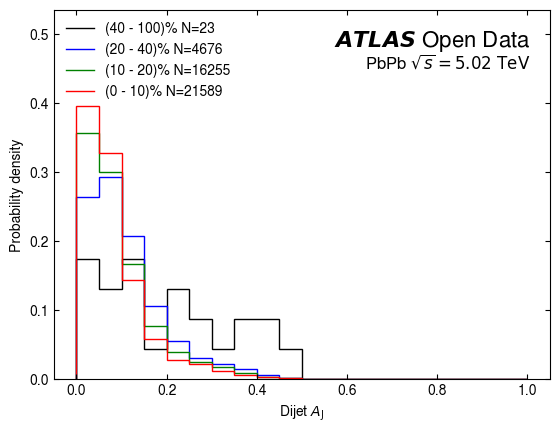

In [198]:
plot_aj_from_dict(H_c,bin_edges)